# *Kapitel 3 - Koduppgifter*

## **13. Datasetet “hr_employee_data.xlsx”**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
%pip install openpyxl

In [3]:
df = pd.read_excel("dataset/hr_employee_data.xlsx")

### **Inspect the dataset**

In [4]:
df.head()

,Emp_Id,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,IND02438,0.38,0.53,2,157,3,0,1,0,sales,low
1,IND28133,0.80,0.86,5,262,6,0,1,0,sales,medium
2,IND07164,0.11,0.88,7,272,4,0,1,0,sales,medium
3,IND30478,0.72,0.87,5,223,5,0,1,0,sales,low
4,IND24003,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
df.shape

(14999, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.5 MB


In [7]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [8]:
df.isna().sum()

Emp_Id                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

### **Explore Categorical Variables**

In [10]:
department_counts = df["Department"].value_counts()

print(department_counts)

Department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


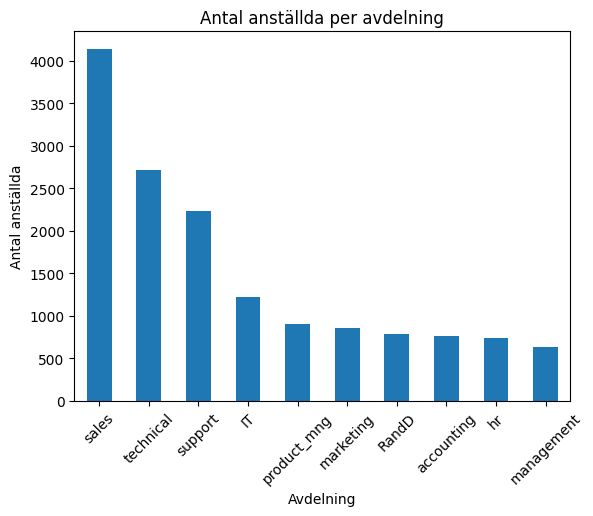

In [11]:
department_counts.plot(kind="bar")

plt.title("Antal anställda per avdelning")
plt.xlabel("Avdelning")
plt.ylabel("Antal anställda")
plt.xticks(rotation=45)
plt.show()

In [12]:
salary_counts = df["salary"].value_counts()

print(salary_counts)

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


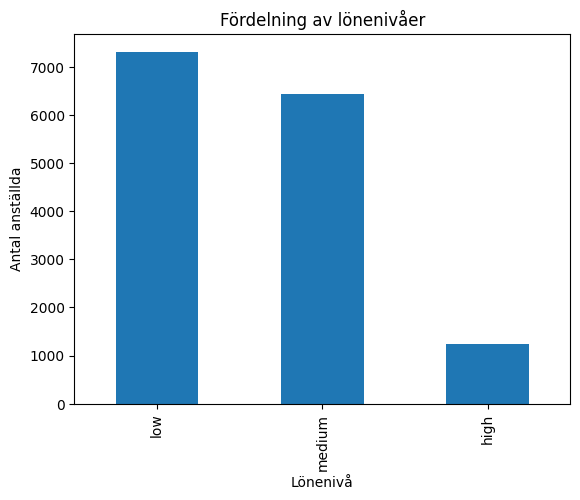

In [13]:
salary_counts.plot(kind="bar")

plt.title("Fördelning av lönenivåer")
plt.xlabel("Lönenivå")
plt.ylabel("Antal anställda")
plt.show()

### **Analyze Numerical Variables**

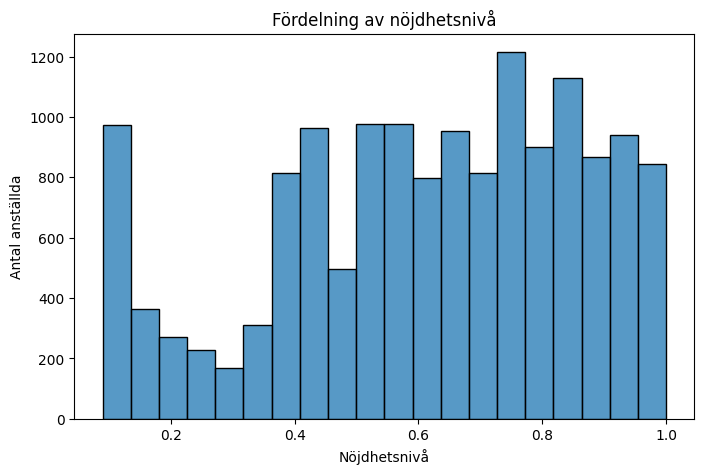

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="satisfaction_level", bins=20)

plt.title("Fördelning av nöjdhetsnivå")
plt.xlabel("Nöjdhetsnivå")
plt.ylabel("Antal anställda")
plt.show()

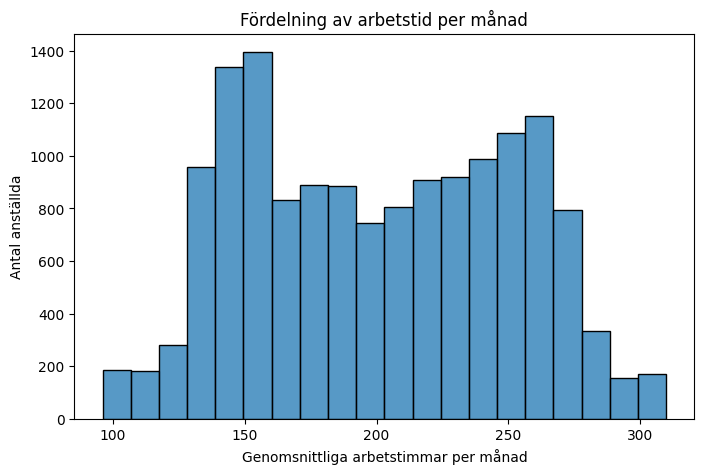

In [15]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="average_montly_hours", bins=20)

plt.title("Fördelning av arbetstid per månad")
plt.xlabel("Genomsnittliga arbetstimmar per månad")
plt.ylabel("Antal anställda")
plt.show()

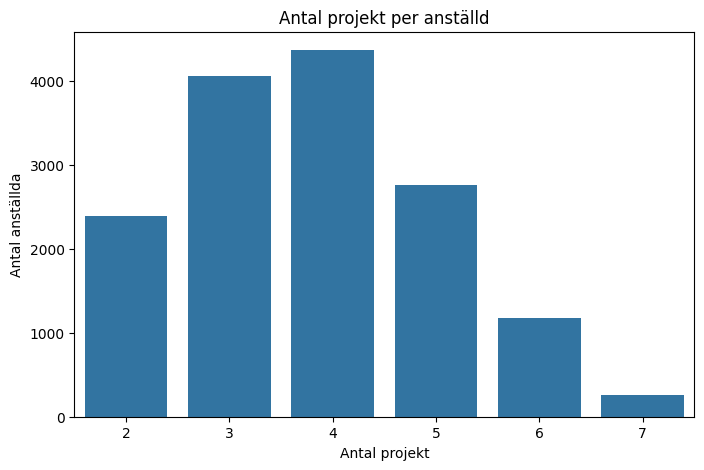

In [16]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="number_project")

plt.title("Antal projekt per anställd")
plt.xlabel("Antal projekt")
plt.ylabel("Antal anställda")
plt.show()

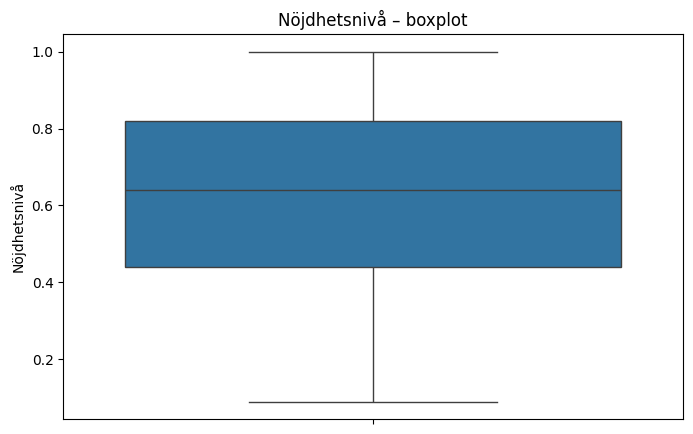

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, y="satisfaction_level")

plt.title("Nöjdhetsnivå – boxplot")
plt.ylabel("Nöjdhetsnivå")
plt.show()

In [18]:
df.groupby("left")["satisfaction_level"].mean()

left
0    0.666810
1    0.440098
Name: satisfaction_level, dtype: float64

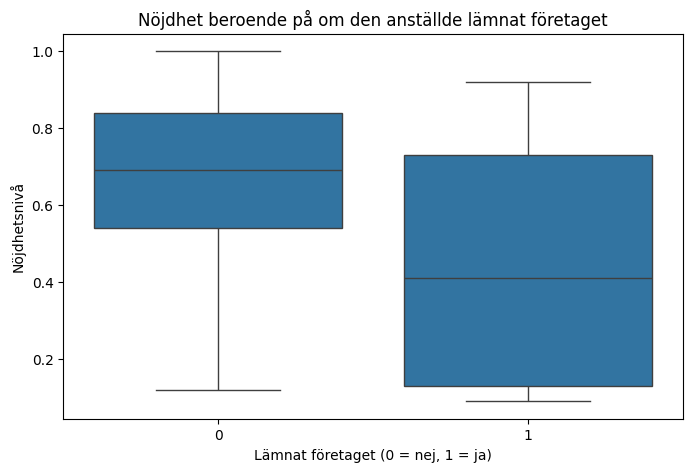

In [19]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="left", y="satisfaction_level")

plt.title("Nöjdhet beroende på om den anställde lämnat företaget")
plt.xlabel("Lämnat företaget (0 = nej, 1 = ja)")
plt.ylabel("Nöjdhetsnivå")
plt.show()

In [20]:
df.groupby("left")["average_montly_hours"].mean()

left
0    199.060203
1    207.419210
Name: average_montly_hours, dtype: float64

In [21]:
df.groupby("left")["time_spend_company"].mean()

left
0    3.380032
1    3.876505
Name: time_spend_company, dtype: float64

In [22]:
df.groupby("left")["number_project"].mean()

left
0    3.786664
1    3.855503
Name: number_project, dtype: float64

### **Analyze Salary**

In [23]:
pd.crosstab(df["salary"], df["left"], normalize="index") * 100

left,0,1
salary,,
high,93.371059,6.628941
low,70.311646,29.688354
medium,79.568725,20.431275


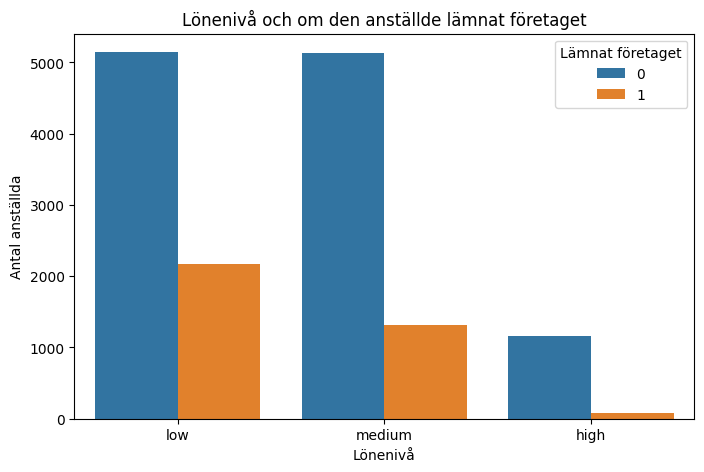

In [24]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="salary", hue="left")

plt.title("Lönenivå och om den anställde lämnat företaget")
plt.xlabel("Lönenivå")
plt.ylabel("Antal anställda")
plt.legend(title="Lämnat företaget")

plt.show()

In [25]:
department_left = pd.crosstab(df["Department"], df["left"], normalize="index") * 100

department_left

left,0,1
Department,,
IT,77.750611,22.249389
RandD,84.625159,15.374841
accounting,73.402868,26.597132
hr,70.906631,29.093369
management,85.555556,14.444444
marketing,76.340326,23.659674
product_mng,78.048780,21.951220
sales,75.507246,24.492754
support,75.100942,24.899058


In [26]:
department_left_sorted = department_left.sort_values(by=1, ascending=False)

department_left_sorted

left,0,1
Department,,
hr,70.906631,29.093369
accounting,73.402868,26.597132
technical,74.375000,25.625000
support,75.100942,24.899058
sales,75.507246,24.492754
marketing,76.340326,23.659674
IT,77.750611,22.249389
product_mng,78.048780,21.951220
RandD,84.625159,15.374841


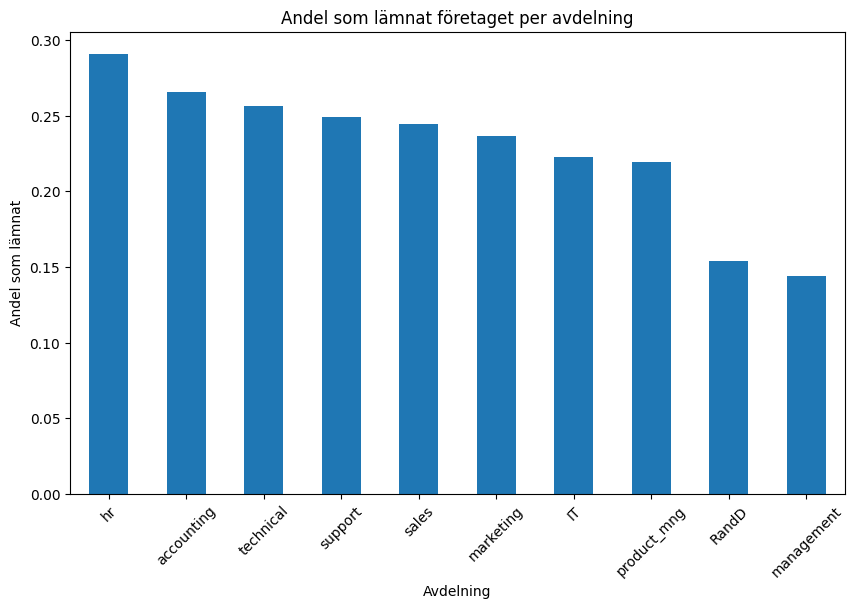

In [27]:
left_by_department = (
    df.groupby("Department")["left"].mean().sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

left_by_department.plot(kind="bar")

plt.title("Andel som lämnat företaget per avdelning")
plt.xlabel("Avdelning")
plt.ylabel("Andel som lämnat")
plt.xticks(rotation=45)
plt.show()

### **Correlation Analysis**

In [28]:
correlation = df.corr(numeric_only=True)

correlation

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
satisfaction_level,1.000000,0.105021,-0.142970,-0.020048,-0.100866,0.058697,-0.388375,0.025605
last_evaluation,0.105021,1.000000,0.349333,0.339742,0.131591,-0.007104,0.006567,-0.008684
number_project,-0.142970,0.349333,1.000000,0.417211,0.196786,-0.004741,0.023787,-0.006064
average_montly_hours,-0.020048,0.339742,0.417211,1.000000,0.127755,-0.010143,0.071287,-0.003544
time_spend_company,-0.100866,0.131591,0.196786,0.127755,1.000000,0.002120,0.144822,0.067433
Work_accident,0.058697,-0.007104,-0.004741,-0.010143,0.002120,1.000000,-0.154622,0.039245
left,-0.388375,0.006567,0.023787,0.071287,0.144822,-0.154622,1.000000,-0.061788
promotion_last_5years,0.025605,-0.008684,-0.006064,-0.003544,0.067433,0.039245,-0.061788,1.000000


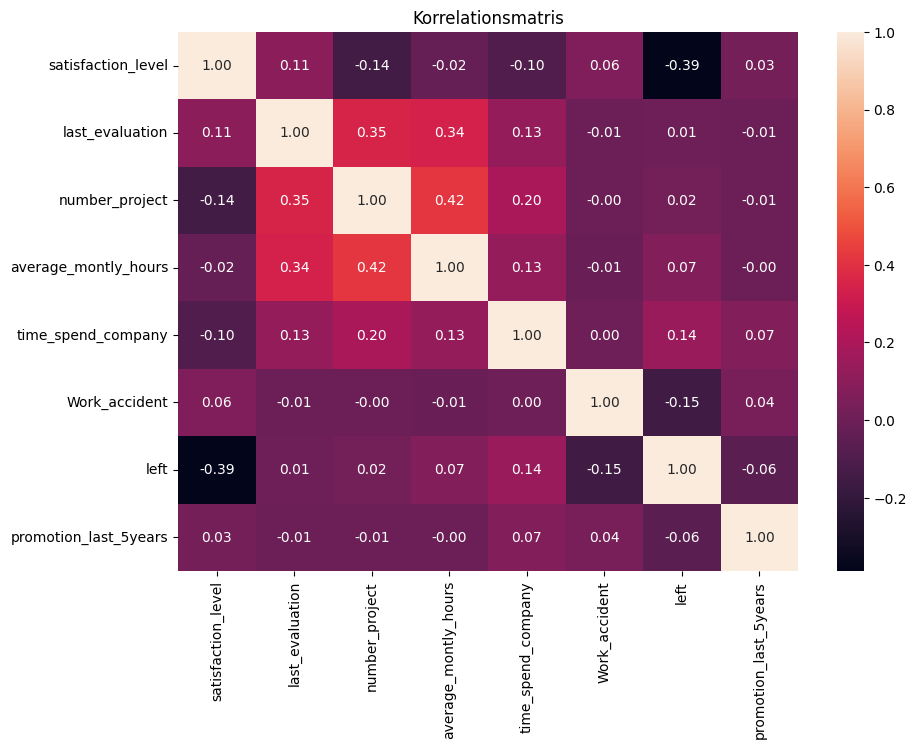

In [29]:
plt.figure(figsize=(10, 7))

sns.heatmap(correlation, annot=True, fmt=".2f")

plt.title("Korrelationsmatris")
plt.show()

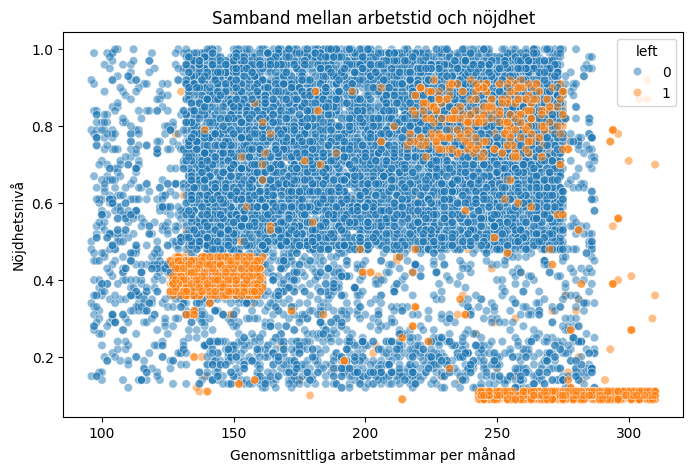

In [30]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df, x="average_montly_hours", y="satisfaction_level", hue="left", alpha=0.5
)

plt.title("Samband mellan arbetstid och nöjdhet")
plt.xlabel("Genomsnittliga arbetstimmar per månad")
plt.ylabel("Nöjdhetsnivå")
plt.show()

### **Summary**

In [31]:
summary = df.groupby("left").agg(
    {
        "satisfaction_level": "mean",
        "last_evaluation": "mean",
        "number_project": "mean",
        "average_montly_hours": "mean",
        "time_spend_company": "mean",
        "Work_accident": "mean",
        "promotion_last_5years": "mean",
    }
)

summary

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


In [32]:
summary_percent = (
    df.groupby("left").agg({"Work_accident": "mean", "promotion_last_5years": "mean"})
    * 100
)

summary_percent

,Work_accident,promotion_last_5years
left,,
0,17.500875,2.625131
1,4.732568,0.532064


### *Analys och slutsatser*

EDA:n visar att datasetet innehåller 14 999 observationer och 11 variabler. Datasetet innehåller både numeriska och kategoriska variabler som beskriver de anställdas exempelvis nöjdhet, utvärdering, antal projekt, arbetstid, tid på företaget, avdelning och lönenivå.

Vid kontroll av datakvaliteten finns inga saknade värden och inga exakta dubbletter. Det innebär att datasetet är komplett ur dessa perspektiv och att vi kan gå vidare med analysen utan att först behöva hantera saknade värden.

Ett tydligt mönster är skillnaden i nöjdhet mellan personer som stannat och personer som lämnat företaget. De som stannat har en genomsnittlig nöjdhetsnivå på ungefär 0,67 medan de som lämnat har en genomsnittlig nivå på ungefär 0,44. Det visar ett tydligt samband mellan nöjdhet och personalomsättning.

Det finns även skillnader i arbetstid. De som lämnat företaget har i genomsnitt arbetat ungefär 207 timmar per månad, jämfört med ungefär 199 timmar bland dem som stannat. Skillnaden är inte i sig ett bevis på att högre arbetstid leder till att anställda slutar, men det är ett mönster som kan vara intressant för företaget att undersöka vidare.

Lönenivåerna visar också en tydlig skillnad. Andelen som lämnat företaget är högst bland anställda med låg lön och lägst bland anställda med hög lön. Detta kan vara relevant för ledningen när man diskuterar löner, karriärmöjligheter och personalomsättning.

Det finns även skillnader mellan företagets olika avdelningar när det gäller andelen anställda som lämnat. Detta kan vara viktigt för ledningen eftersom en hög personalomsättning i en viss avdelning kan motivera en närmare undersökning av exempelvis arbetsmiljö, arbetsbelastning, ledarskap och utvecklingsmöjligheter.

Det är samtidigt viktigt att komma ihåg att EDA främst visar mönster och samband. Vi kan inte utifrån denna analys säga att en viss faktor automatiskt orsakar att en anställd lämnar företaget. Resultaten kan däremot användas för att identifiera områden som företaget bör undersöka vidare.

Sammanfattningsvis visar analysen att det finns flera intressanta samband i personaldatan, framför allt kopplade till nöjdhet, lön, arbetstid och avdelning. EDA visar därför att man kan få fram användbara insikter för ledningen även utan att bygga någon ML-modell.

## **16. Datasetet "diamonds.csv"**

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

In [34]:
df = pd.read_csv("dataset/diamonds.csv")

### **Inspect the Dataset**

In [35]:
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 5.1 MB


In [37]:
df.shape

(53940, 11)

In [38]:
df.dtypes

Unnamed: 0      int64
carat         float64
cut               str
color             str
clarity           str
depth         float64
table         float64
price           int64
x             float64
y             float64
z             float64
dtype: object

### **Data Cleaning**

In [39]:
df.isna().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [40]:
df = df.drop(columns=["Unnamed: 0"])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### **Encode Categorical Variables**

In [41]:
df = pd.get_dummies(df, columns=["cut", "color", "clarity"], drop_first=True)

### **Define Features and Target**

In [42]:
X = df.drop(columns=["price"])
y = df["price"]

### **Train-Validation-Test Split**

In [43]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.15, random_state=42)

In [44]:
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (36679, 23)
Validation size: (6473, 23)
Test size: (10788, 23)


### **Train Regression Models**

In [45]:
#Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
lin_reg_pred = lin_reg.predict(X_val)

In [46]:
# Random Forest
random_forest = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(X_train, y_train)

rf_pred = random_forest.predict(X_val)

### **Evaluate Models**

In [47]:
# Linear Regression
lin_reg_rmse = root_mean_squared_error(y_val, lin_reg_pred)

print("Linear Regression RMSE:", lin_reg_rmse)

Linear Regression RMSE: 1101.9350875347309


In [48]:
# Random Forest
rf_rmse = root_mean_squared_error(
    y_val,
    rf_pred
)

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 611.6320218755886


### **Hyperparameter Tuning**

In [49]:
tree_reg = DecisionTreeRegressor(random_state=42)

hyperparams = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

tree_reg_gs = GridSearchCV(
    tree_reg, hyperparams, scoring="neg_root_mean_squared_error", cv=5, n_jobs=-1
)

tree_reg_gs.fit(X_train, y_train)

print(tree_reg_gs.best_params_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [50]:
tree_pred = tree_reg_gs.predict(X_val)

tree_rmse = root_mean_squared_error(
    y_val,
    tree_pred
)

print("Decision Tree RMSE:", tree_rmse)

Decision Tree RMSE: 752.0013279347713


### **Compare Models**

In [51]:
print("Linear Regression RMSE:", lin_reg_rmse)
print("Decision Tree RMSE:", tree_rmse)
print("Random Forest RMSE:", rf_rmse)

Linear Regression RMSE: 1101.9350875347309
Decision Tree RMSE: 752.0013279347713
Random Forest RMSE: 611.6320218755886


### **Final Model**

In [52]:
# Random Forest hade lägst RMSE på valideringsdatan
best_model = random_forest

best_model.fit(X_train_full, y_train_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"ma

### **Final Test Evaluation**

In [53]:
pred_test = best_model.predict(X_test)

In [54]:
test_rmse = root_mean_squared_error(y_test, pred_test)

print("Random Forest Test RMSE:", test_rmse)

Random Forest Test RMSE: 646.7604742584186


### **Analysis**

Jag testade tre olika regressionsmodeller för att förutsäga diamantpriset: Linear Regression, Decision Tree och Random Forest. Modellerna utvärderades på valideringsdatan med RMSE, där ett lägre värde innebär bättre resultat.

Linear Regression fick ett RMSE på cirka 1102, medan Decision Tree efter hyperparameter tuning fick ett RMSE på cirka 752. Random Forest fick det lägsta RMSE-värdet på cirka 612 och valdes därför som den bästa modellen utifrån valideringsdatan.

Den valda Random Forest-modellen tränades sedan om på både tränings och valideringsdatan och utvärderades slutligen på den separata testdatan. På testdatan fick modellen ett RMSE på cirka 647. Resultatet ligger nära modellens resultat på valideringsdatan, vilket visar att modellen presterade relativt likartat på den data som inte användes vid träningen.

Sammanfattningsvis gav Random Forest bäst resultat av de modeller som testades och kunde förutsäga diamantpriser med ett RMSE på cirka 647 på testdatan.